# TASK 05 — Gradient Descent in 2D on a Contour Plot

In this task, I will implement gradient descent in two dimensions.

The function is:

f(x, y) = x² + 3y²

Its gradient is:

∇f(x, y) = [2x, 6y]

The known minimum is [0, 0].

I will start from [4, 4], visualize the function using a contour plot,
and show the gradient descent path toward the minimum.

## 2D Gradient Descent

In 1D, gradient descent updates one variable:

x_new = x - learning_rate × gradient

In 2D, the gradient becomes a vector containing the partial derivatives
with respect to x and y:

∇f(x, y) = [df/dx, df/dy]

For this function:

df/dx = 2x
df/dy = 6y

Therefore:

∇f(x, y) = [2x, 6y]

The update is applied to both coordinates simultaneously.

FIRST SIX POSITIONS
Step 0: x = 4.000000, y = 4.000000
Step 1: x = 3.200000, y = 1.600000
Step 2: x = 2.560000, y = 0.640000
Step 3: x = 2.048000, y = 0.256000
Step 4: x = 1.638400, y = 0.102400
Step 5: x = 1.310720, y = 0.040960

FINAL POSITION
x = 0.000532, y = 0.000000

Known minimum: [0, 0]


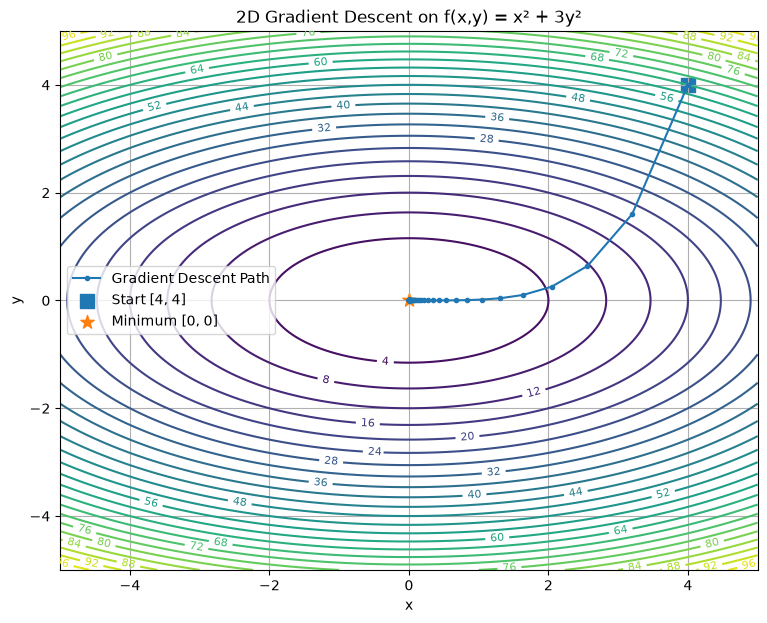


SECOND EXPERIMENT
Starting point: [-4.0, 3.0]
Learning rate: 0.05
Final point: [-0.007188, 0.000000]


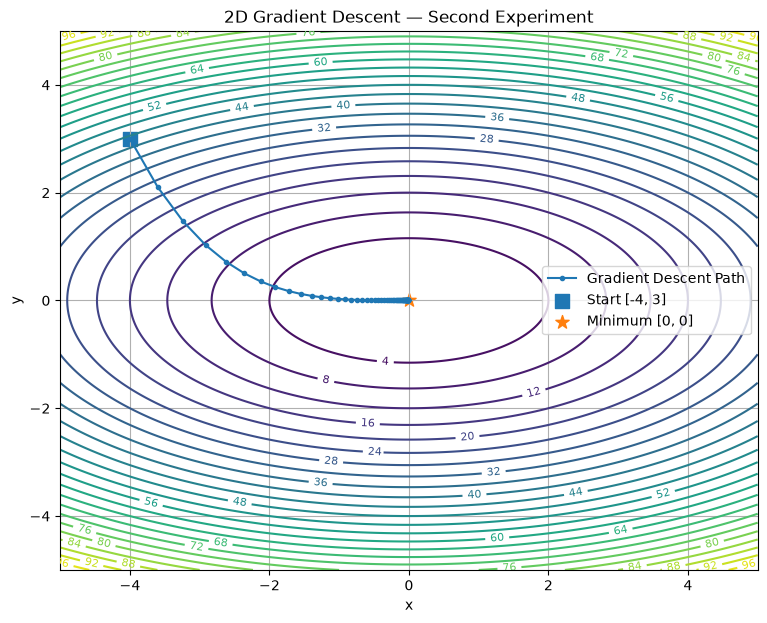


FINAL SUMMARY
Function: f(x,y) = x² + 3y²
Gradient: [2x, 6y]
Known minimum: [0, 0]
Experiment 1 ended at: [0.000532, 0.000000]
Experiment 2 ended at: [-0.007188, 0.000000]


In [2]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# TASK 05 — 2D Gradient Descent
# ============================================================

# ------------------------------------------------------------
# Function
# f(x, y) = x² + 3y²
# ------------------------------------------------------------

def f(x, y):
    return x**2 + 3*y**2


# ------------------------------------------------------------
# Gradient
# ∇f = [2x, 6y]
# ------------------------------------------------------------

def grad(point):
    x, y = point

    return np.array([
        2 * x,
        6 * y
    ])


# ------------------------------------------------------------
# Reusable 2D Gradient Descent
# ------------------------------------------------------------

def gradient_descent_2d(grad_fn, start, lr, steps):

    point = np.array(start, dtype=float)

    history = [point.copy()]

    for _ in range(steps):

        gradient = grad_fn(point)

        point = point - lr * gradient

        history.append(point.copy())

    return np.array(history)


# ============================================================
# Experiment 1 — Start at [4, 4]
# ============================================================

start = [4.0, 4.0]

lr = 0.1

steps = 40

path = gradient_descent_2d(
    grad_fn=grad,
    start=start,
    lr=lr,
    steps=steps
)


# ------------------------------------------------------------
# Print first few positions
# ------------------------------------------------------------

print("FIRST SIX POSITIONS")
print("=" * 50)

for i, point in enumerate(path[:6]):

    print(
        f"Step {i}: "
        f"x = {point[0]:.6f}, "
        f"y = {point[1]:.6f}"
    )


# ------------------------------------------------------------
# Final position
# ------------------------------------------------------------

final_point = path[-1]

print("\nFINAL POSITION")
print("=" * 50)

print(
    f"x = {final_point[0]:.6f}, "
    f"y = {final_point[1]:.6f}"
)

print("\nKnown minimum: [0, 0]")


# ============================================================
# Contour Plot
# ============================================================

x_values = np.linspace(-5, 5, 400)

y_values = np.linspace(-5, 5, 400)

X, Y = np.meshgrid(x_values, y_values)

Z = f(X, Y)


plt.figure(figsize=(9, 7))

# Draw contour lines
contours = plt.contour(
    X,
    Y,
    Z,
    levels=25
)

plt.clabel(
    contours,
    inline=True,
    fontsize=8
)


# Draw gradient descent path
plt.plot(
    path[:, 0],
    path[:, 1],
    marker="o",
    markersize=3,
    linestyle="-",
    label="Gradient Descent Path"
)


# Starting point
plt.scatter(
    path[0, 0],
    path[0, 1],
    s=100,
    marker="s",
    label="Start [4, 4]"
)


# Minimum
plt.scatter(
    0,
    0,
    s=100,
    marker="*",
    label="Minimum [0, 0]"
)


plt.xlabel("x")

plt.ylabel("y")

plt.title(
    "2D Gradient Descent on f(x,y) = x² + 3y²"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# Experiment 2 — Different Starting Point and Learning Rate
# ============================================================

start_2 = [-4.0, 3.0]

lr_2 = 0.05

steps_2 = 60


path_2 = gradient_descent_2d(
    grad_fn=grad,
    start=start_2,
    lr=lr_2,
    steps=steps_2
)


# ------------------------------------------------------------
# Print second experiment result
# ------------------------------------------------------------

print("\nSECOND EXPERIMENT")
print("=" * 50)

print(f"Starting point: {start_2}")

print(f"Learning rate: {lr_2}")

print(
    f"Final point: "
    f"[{path_2[-1, 0]:.6f}, "
    f"{path_2[-1, 1]:.6f}]"
)


# ------------------------------------------------------------
# Plot second path
# ------------------------------------------------------------

plt.figure(figsize=(9, 7))

contours = plt.contour(
    X,
    Y,
    Z,
    levels=25
)

plt.clabel(
    contours,
    inline=True,
    fontsize=8
)


plt.plot(
    path_2[:, 0],
    path_2[:, 1],
    marker="o",
    markersize=3,
    linestyle="-",
    label="Gradient Descent Path"
)


plt.scatter(
    path_2[0, 0],
    path_2[0, 1],
    s=100,
    marker="s",
    label="Start [-4, 3]"
)


plt.scatter(
    0,
    0,
    s=100,
    marker="*",
    label="Minimum [0, 0]"
)


plt.xlabel("x")

plt.ylabel("y")

plt.title(
    "2D Gradient Descent — Second Experiment"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# Final Summary
# ============================================================

print("\nFINAL SUMMARY")
print("=" * 50)

print("Function: f(x,y) = x² + 3y²")

print("Gradient: [2x, 6y]")

print("Known minimum: [0, 0]")

print(
    f"Experiment 1 ended at: "
    f"[{path[-1,0]:.6f}, {path[-1,1]:.6f}]"
)

print(
    f"Experiment 2 ended at: "
    f"[{path_2[-1,0]:.6f}, {path_2[-1,1]:.6f}]"
)

## Why Does the Path Curve?

The function is:

f(x,y) = x² + 3y²

The gradient is:

∇f = [2x, 6y]

Notice that the y component has a larger coefficient:

6y > 2x

This means the function is steeper in the y direction than in the x
direction.

Therefore, gradient descent makes a stronger correction in the y
direction while also changing x.

As the point moves, the balance between the x and y gradients changes.
This causes the descent path to bend rather than simply moving in a
straight line toward [0, 0].

## 1D Gradient Descent vs 2D Gradient Descent

In one dimension:

x_new = x - learning_rate * gradient

The gradient is one number.

In two dimensions:

[x_new, y_new] =
[x, y] - learning_rate * [df/dx, df/dy]

The gradient is now a vector.

The fundamental idea is still exactly the same:

new position = old position - learning_rate × gradient

The only difference is that every parameter gets its own gradient
component and is updated simultaneously.

## What Is the Contour Plot in a Real Neural Network?

In this example, the function has only two variables, x and y, so we
can visualize its landscape using a 2D contour plot.

A real neural network may have millions of parameters:

w1, w2, w3, ..., wN

The loss function therefore exists in a space with millions of
dimensions.

The contour plot would require visualizing this extremely
high-dimensional space, which cannot be directly drawn on a normal
2D screen.

The same gradient-descent idea still works, but the optimizer operates
on a high-dimensional parameter vector instead of a visible point
[x, y].